# M1.Ex1: Model Hours vs Marks

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex1_reg.ipynb)
- Raw Dataset: [Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Step 1. Load the data

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv")
df.head()

,Hours_Studied,Marks
0,4.76,46.27
1,3.00,34.30
2,2.08,33.63
3,4.04,47.81
4,9.49,66.26


### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
X = df[["Hours_Studied"]]   # features
y = df["Marks"]             # target

### Step 2.b print the type of each

In [4]:
X.dtypes

,0
Hours_Studied,float64


In [5]:
y.dtypes

dtype('float64')

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

* Target is: numerical (Marks)
* Task is: regression

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [ ]:
#   X = data matrix - input
#   y = target - output

In [6]:
print("X shape:", X.shape)     # (rows, columns) --> (samples , features) -- 2D

X shape: (100, 1)


In [7]:
print("y shape:", y.shape)     # (rows,)   --> (traget values) 100 values = one mark per student -- 1D

y shape: (100,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [8]:
df.describe()

,Hours_Studied,Marks
count,100.000000,100.000000
mean,5.376300,46.360200
std,2.593013,14.284805
min,1.050000,20.190000
25%,3.175000,33.675000
50%,5.565000,47.485000
75%,7.255000,57.377500
max,9.870000,73.260000


### Step 5. Plot the feature vs the target

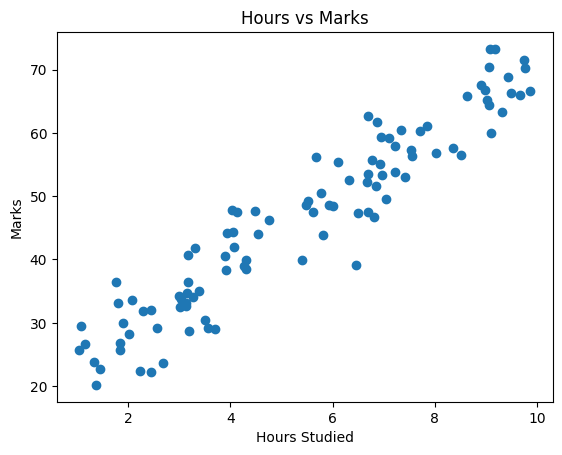

In [9]:
plt.scatter(X, y)
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Hours vs Marks")
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

* Increasing, as we see from the scatter plot more study hours = higher marks.


### Step 7. Initialize a `LinearRegression` model

In [10]:
model = LinearRegression()

### Step 8. Split the dataset into train and test sets

Explain:

* test_size=0.2 ---> 20% test data , 80% train data
* random_state=42 ---> to control split randomness, Make train/test split identical each time. Makes results reproducible


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Step 9.a Train the model on the training set

In [12]:
model.fit(X_train, y_train)

LinearRegression()

### Step 9.b Identify the learned slope and the y-intercept of the model

Explain:

The slope-intercept form of a linear equation is **y = mx + b**, where m is the slope (steepness) and b is the y- intercept (the
point where the line crosses the y- axis at (0,b)).

In [13]:
slope = round(model.coef_[0])
intercept = round(model.intercept_)

print("Slope is:", slope)
print("Intercept is:", intercept)

Slope is: 5
Intercept is: 19


### Step 9.c how much marks do we get per 1 hour of study?

In [14]:
# slope, meaning each extra hour of study adds 5 marks

print("The marks per 1 hour of study = ", slope)

The marks per 1 hour of study =  5


### Step 9.d how much does a 10 minutes increase of study time adds to our marks?

In [15]:
# convert minutes to hours --> 1 hour = 60 minutes --> 10/60

increase_ten_minute = slope * (10/60)
print("The marks per 10 minutes of study =", round(increase_ten_minute,2))

The marks per 10 minutes of study = 0.83


### Step 9.e if one doesn't study at all, how much marks do they get?

Explain: y = mx + b

Marks = (Slope × Hours_Studied) + Intercept

Marks = (Slope × 0) + Intercept

Marks = (0) + Intercept

Marks = Intercept

In [16]:
print("Marks without studying at all = ", intercept)

Marks without studying at all =  19


### Step 10. Evaluate the model on the test set

In [17]:
model.score(X_test, y_test)

0.9258085525213727

### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [18]:
sample_values = X_test.sample(3, random_state=42)
predicted_values = model.predict(sample_values)

check_matching = pd.DataFrame({
"Hours_Studied" : sample_values["Hours_Studied"],
"Predicted_Values (Marks)" : predicted_values,
"True_Values (Marks)" : y_test.loc[sample_values.index]
})

check_matching

,Hours_Studied,Predicted_Values (Marks),True_Values (Marks)
83,3.02,34.135183,32.50
77,6.97,54.534714,53.36
4,9.49,67.549099,66.26


### Step 12. Plot the data and the regression line

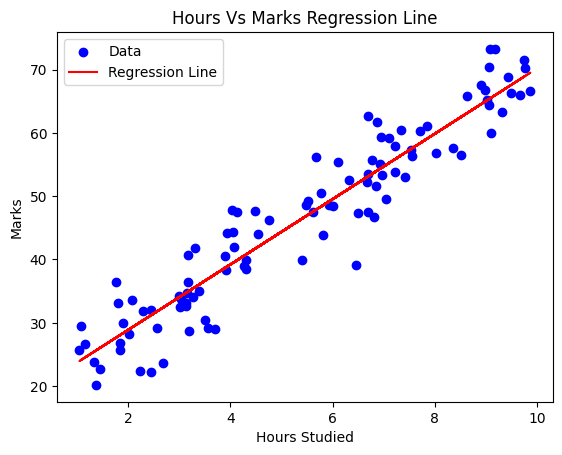

In [19]:
plt.scatter(X, y, color="blue" , label="Data")
plt.plot(X, model.predict(X), color="red", label="Regression Line")
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Hours Vs Marks Regression Line")
plt.legend()
plt.show()